# Chest X-Ray Anomaly Detection

## Problem Tanımı

Bu projede göğüs röntgeni (Chest X-Ray) görüntülerinde anormal bir bulgu bulunup bulunmadığını tespit eden bir derin öğrenme modeli geliştirilmesi amaçlanmıştır.

Çalışmada VinDr-Chest veri seti kullanılmıştır. Modelin görevi görüntüleri aşağıdaki iki sınıfa ayırmaktır:

* **0 → Normal**
* **1 → Anormal (Finding)**

Proje kapsamında veri keşfi ve görselleştirme (EDA), görüntü ön işleme (Preprocessing), veri artırma (Data Augmentation), Transfer Learning, Fine-Tuning ve Attention Mechanism yaklaşımları uygulanmıştır.

Model performansı Accuracy, Recall (Sensitivity), Specificity, F1-Score, ROC-AUC ve Confusion Matrix metrikleri kullanılarak değerlendirilmiştir.


## 1. Gerekli Kütüphanelerin Yüklenmesi

Bu bölümde veri analizi, görüntü işleme, görselleştirme, derin öğrenme ve model değerlendirme aşamalarında kullanılacak kütüphaneler yüklenmiştir.

In [58]:
# --------------------------------------------------
# Gerekli Kütüphanelerin Yüklenmesi
# --------------------------------------------------

# Dosya ve klasör işlemleri
import os

# Sayısal işlemler ve matris işlemleri
import numpy as np

# Veri analizi ve tablo işlemleri
import pandas as pd

# Grafik çizimleri
import matplotlib.pyplot as plt

# Görüntü işleme işlemleri (CLAHE, filtreleme vb.)
import cv2

# Model değerlendirme metrikleri
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import roc_curve, auc

# Derin öğrenme ve görüntü veri yükleme işlemleri
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

print("Kütüphaneler başarıyla yüklendi.")

Kütüphaneler başarıyla yüklendi.


## 2. Veri Setinin İncelenmesi (EDA)

Bu bölümde veri setindeki Normal (0) ve Anormal (1) sınıflarına ait görüntü sayıları incelenmiştir.

Amaç, eğitim (train), doğrulama (validation) ve test veri setlerinde sınıf dağılımlarını analiz ederek sınıf dengesizliği (class imbalance) problemi olup olmadığını belirlemektir.

In [59]:
# --------------------------------------------------
# Veri Seti Yollarının Tanımlanması
# --------------------------------------------------

train_dir = "../dataset/ChestXray_Classification/train"
valid_dir = "../dataset/ChestXray_Classification/valid"
test_dir  = "../dataset/ChestXray_Classification/test"


# --------------------------------------------------
# Bir klasördeki görüntü sayısını hesaplayan fonksiyon
# --------------------------------------------------

def count_images(folder_path):

    return len([
        f for f in os.listdir(folder_path)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ])


# --------------------------------------------------
# Train, Validation ve Test setleri için
# sınıf dağılımlarını hesapla
# --------------------------------------------------

for split_name, split_path in {

    "Train": train_dir,
    "Validation": valid_dir,
    "Test": test_dir

}.items():

    normal_count = count_images(
        os.path.join(split_path, "0")
    )

    anomaly_count = count_images(
        os.path.join(split_path, "1")
    )

    print(f"\n{split_name} Seti")
    print(f"Normal (0): {normal_count}")
    print(f"Anormal (1): {anomaly_count}")


Train Seti
Normal (0): 4277
Anormal (1): 4277

Validation Seti
Normal (0): 535
Anormal (1): 535

Test Seti
Normal (0): 535
Anormal (1): 535


### Sınıf Dağılımı Değerlendirmesi

Yapılan inceleme sonucunda eğitim, doğrulama ve test veri setlerinde Normal (0) ve Anormal (1) sınıflarının eşit sayıda örnek içerdiği görülmüştür.

Bu durum veri setinde sınıf dengesizliği (class imbalance) problemi bulunmadığını göstermektedir.

Dengeli veri setleri, modelin belirli bir sınıfa yönelmesini engelleyerek daha güvenilir sonuçlar üretmesine katkı sağlamaktadır. Özellikle tıbbi görüntü sınıflandırma problemlerinde sınıf dengesinin korunması büyük önem taşımaktadır.

## 2. Örnek Görselleştirme

Bu bölümde veri setindeki Normal ve Anormal sınıflara ait örnek görüntüler incelenmiştir.

Amaç, iki sınıfın görsel yapısını gözlemlemek ve veri setini daha yakından tanımaktır.

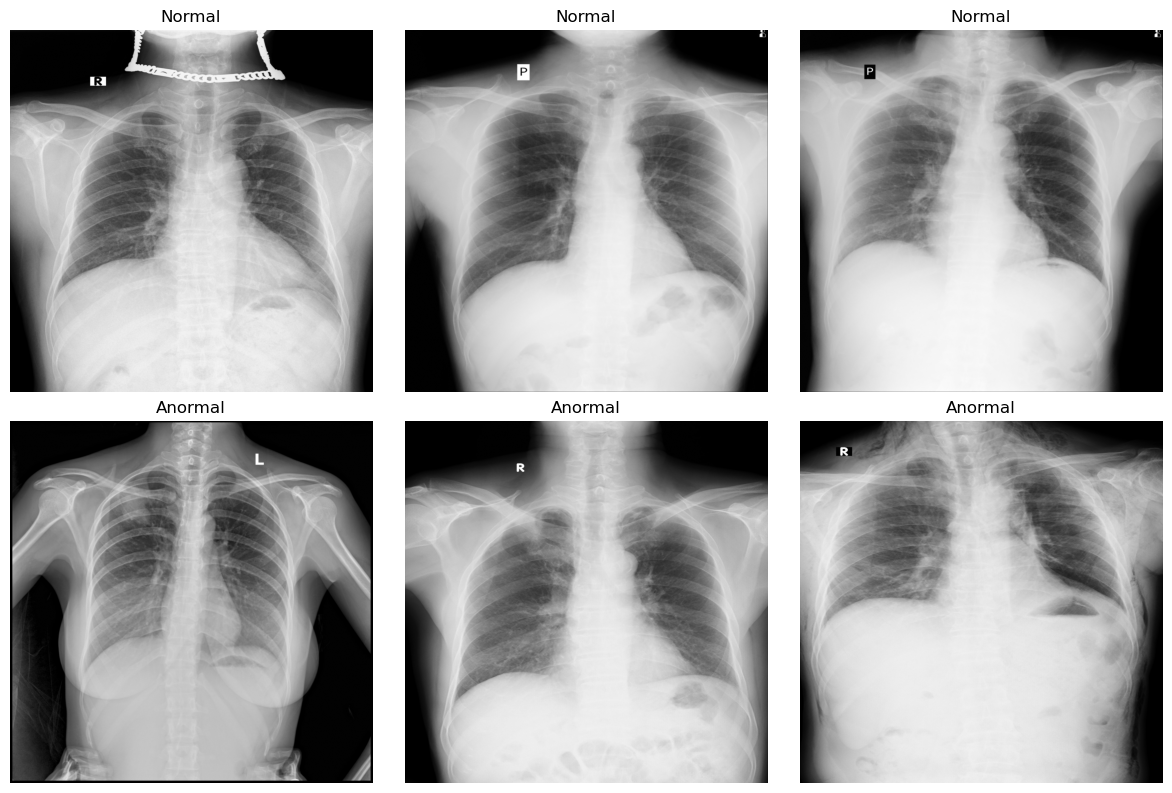

: 

In [ ]:
# Normal ve Anormal sınıflardan örnek görüntüleri gösterme

normal_folder = "../dataset/ChestXray_Classification/train/0"
anomaly_folder = "../dataset/ChestXray_Classification/train/1"

normal_images = os.listdir(normal_folder)[:3]
anomaly_images = os.listdir(anomaly_folder)[:3]

plt.figure(figsize=(12, 8))

# Normal görüntüler
for i, image_name in enumerate(normal_images):

    image_path = os.path.join(normal_folder, image_name)

    image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

    plt.subplot(2, 3, i + 1)
    plt.imshow(image, cmap="gray")
    plt.title("Normal")
    plt.axis("off")

# Anormal görüntüler
for i, image_name in enumerate(anomaly_images):

    image_path = os.path.join(anomaly_folder, image_name)

    image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

    plt.subplot(2, 3, i + 4)
    plt.imshow(image, cmap="gray")
    plt.title("Anormal")
    plt.axis("off")

plt.tight_layout()
plt.show()

### Görüntülerin İncelenmesi

Her iki sınıftan örnek görüntüler incelendiğinde görüntülerin gri tonlu (grayscale) göğüs röntgenlerinden oluştuğu görülmektedir.

Normal ve Anormal görüntüler arasında bazı görsel farklılıklar bulunmasına rağmen bu farklılıklar her zaman insan gözüyle kolayca ayırt edilemeyebilir. Bu nedenle derin öğrenme yöntemleri kullanılarak otomatik sınıflandırma yapılması hedeflenmektedir.

### Ortalama Histogram Analizi

Tek bir görüntü üzerinden yapılan histogram analizi veri setinin genel yapısını temsil etmeyebilir. Bu nedenle her sınıftan birden fazla görüntü kullanılarak ortalama histogramlar hesaplanmıştır.

Bu yaklaşım, Normal ve Anormal sınıfların genel parlaklık ve kontrast özelliklerinin daha güvenilir şekilde incelenmesini sağlamaktadır.

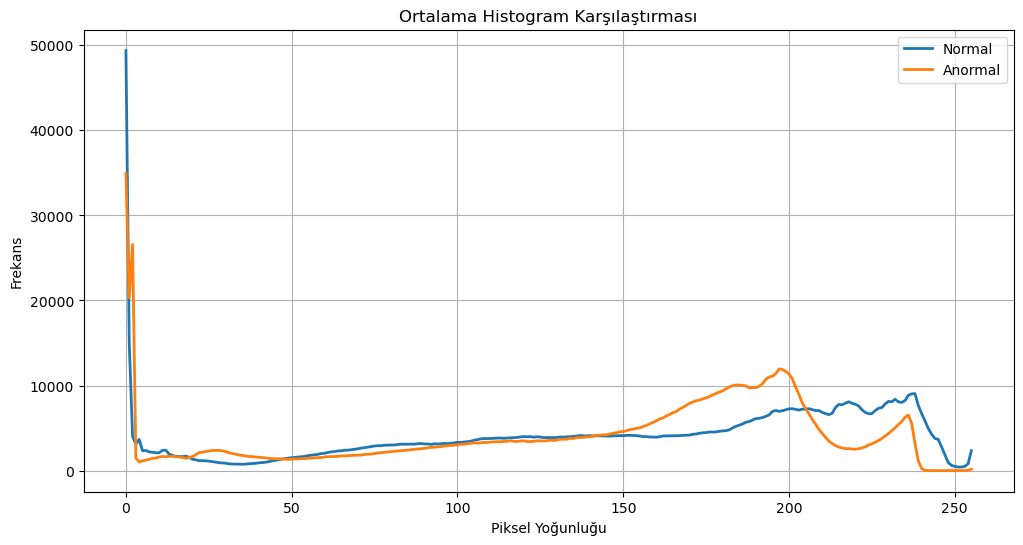

: 

In [ ]:
# Ortalama histogram analizi

# Her sınıf için histogram değerlerini sakla
normal_hist = np.zeros(256)
anomaly_hist = np.zeros(256)

# Analizde kullanılacak görüntü sayısı
num_images = 10

# Normal sınıf histogramları

for image_name in os.listdir(normal_folder)[:num_images]:

    image_path = os.path.join(normal_folder, image_name)

    image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

    hist = cv2.calcHist(
        [image],
        [0],
        None,
        [256],
        [0, 256]
    )

    normal_hist += hist.flatten()

# Anormal sınıf histogramları
for image_name in os.listdir(anomaly_folder)[:num_images]:

    image_path = os.path.join(anomaly_folder, image_name)

    image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

    hist = cv2.calcHist(
        [image],
        [0],
        None,
        [256],
        [0, 256]
    )

    anomaly_hist += hist.flatten()

# Ortalama histogramları hesapla
normal_hist = normal_hist / num_images
anomaly_hist = anomaly_hist / num_images

# Histogramları görselleştir
plt.figure(figsize=(12,6))

plt.plot(normal_hist, label="Normal", linewidth=2)
plt.plot(anomaly_hist, label="Anormal", linewidth=2)

plt.title("Ortalama Histogram Karşılaştırması")
plt.xlabel("Piksel Yoğunluğu")
plt.ylabel("Frekans")

plt.legend()
plt.grid(True)

plt.show()

### Histogram Değerlendirmesi

Normal ve Anormal sınıflardan seçilen 10'ar görüntü kullanılarak ortalama histogramlar oluşturulmuştur.

Histogramlar incelendiğinde iki sınıfın piksel yoğunluğu dağılımlarında belirli farklılıklar olduğu görülmektedir. Özellikle orta ve yüksek yoğunluk bölgelerinde Anormal sınıfa ait görüntülerin farklı bir dağılım sergilediği gözlemlenmiştir.

Bu durum, görüntülerin kontrast ve parlaklık özelliklerinin sınıflara göre değişebildiğini göstermektedir. Elde edilen sonuçlar, görüntü iyileştirme yöntemlerinin uygulanmasının model performansına katkı sağlayabileceğini düşündürmektedir.

# B. Veri Ön İşleme (Preprocessing)

## 4. Görüntü İyileştirme Yöntemleri

Tıbbi görüntüler ham halleriyle düşük kontrastlı veya gürültülü olabilmektedir.

Bu nedenle model eğitiminden önce görüntü kalitesini artırmak amacıyla çeşitli ön işleme yöntemleri uygulanmıştır.

Bu çalışmada:

- Histogram Equalization
- CLAHE
- Gaussian Blur
- Median Blur

yöntemleri değerlendirilmiştir.Amaç, görüntü kalitesini artırırken anatomik detayların korunmasını sağlamaktır.

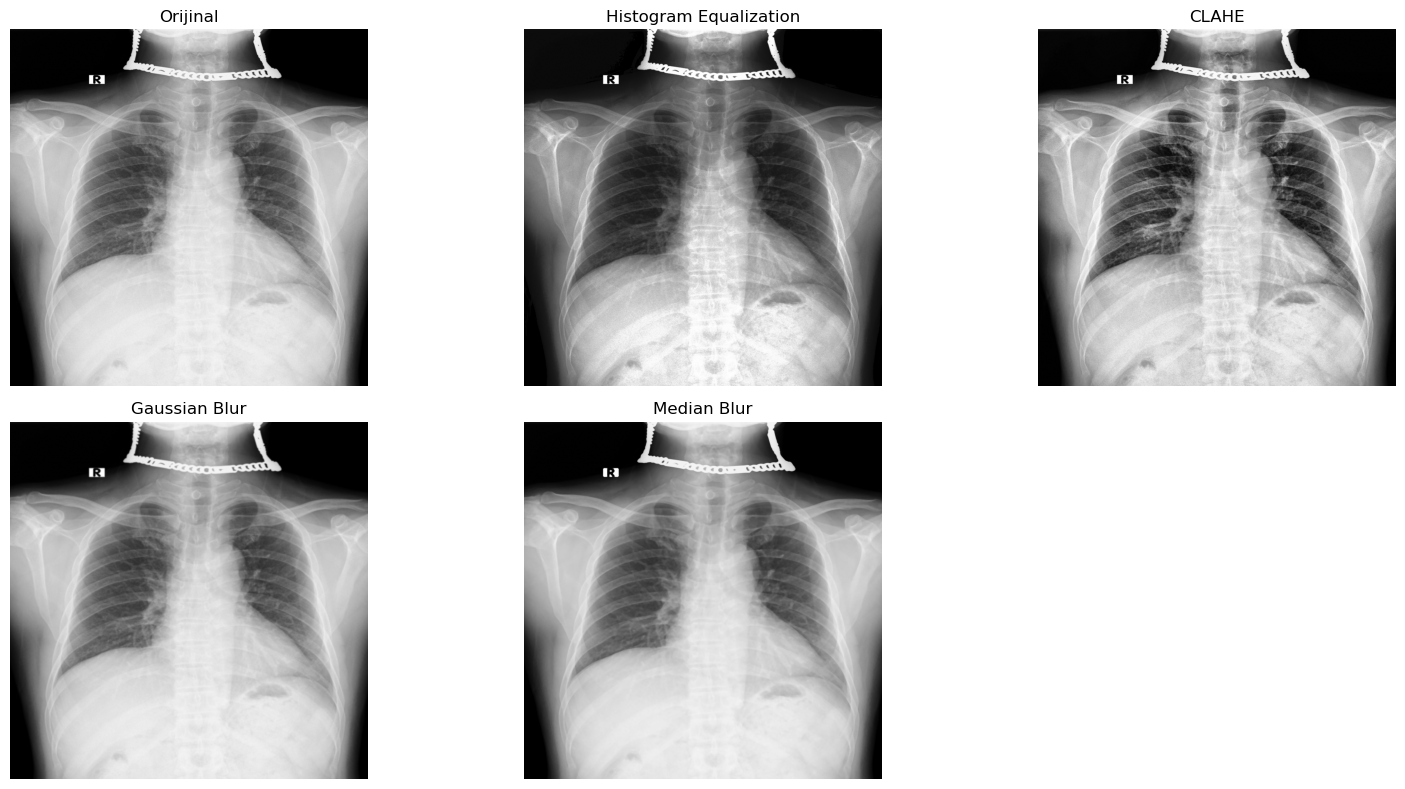

: 

In [ ]:
# Örnek görüntü

image = cv2.imread(
    sample_image_path,
    cv2.IMREAD_GRAYSCALE
)

# # Histogram Equalization
# Global kontrast artırma yöntemi
hist_eq = cv2.equalizeHist(image)

# CLAH
# Lokal kontrast artırma yöntemi
clahe = cv2.createCLAHE(
    clipLimit=2.0,
    tileGridSize=(8,8)
)

clahe_image = clahe.apply(image)

# Gaussian Blur Gürültü azaltma filtresi
gaussian = cv2.GaussianBlur(
    image,
    (5,5),
    0
)

# Median Blur
# Tuz-biber gürültüsünü azaltmak için kullanılır
median = cv2.medianBlur(
    image,
    5
)

# Sonuçları görselleştir

plt.figure(figsize=(16,8))

titles = [
    "Orijinal",
    "Histogram Equalization",
    "CLAHE",
    "Gaussian Blur",
    "Median Blur"
]

images = [
    image,
    hist_eq,
    clahe_image,
    gaussian,
    median
]

for i in range(5):

    plt.subplot(2,3,i+1)

    plt.imshow(
        images[i],
        cmap="gray"
    )

    plt.title(titles[i])

    plt.axis("off")

plt.tight_layout()
plt.show()

### Görüntü İyileştirme Değerlendirmesi

Farklı görüntü iyileştirme yöntemleri karşılaştırılmıştır.

Histogram Equalization yöntemi görüntü kontrastını artırmasına rağmen bazı bölgelerde aşırı parlaklaşmaya neden olmuştur. Gaussian Blur ve Median Blur yöntemleri görüntüdeki gürültüyü azaltmış ancak bazı ince anatomik detayların kaybolmasına yol açmıştır.

CLAHE yöntemi ise kontrastı artırırken akciğer bölgelerindeki detayları daha iyi korumuş ve görüntü kalitesini dengeli bir şekilde iyileştirmiştir. Bu nedenle çalışmanın sonraki aşamalarında CLAHE yöntemi tercih edilmiştir.

## 5. Data Augmentation

Derin öğrenme modellerinin farklı görüntü varyasyonlarını öğrenebilmesi amacıyla veri artırma (Data Augmentation) yöntemleri incelenmiştir.

Bu bölümde veri artırma işlemlerinin etkisini göstermek amacıyla örnek dönüşümler uygulanmıştır. Asıl veri artırma işlemleri model eğitimi sırasında ImageDataGenerator kullanılarak gerçekleştirilecektir.

Bu kapsamda aşağıdaki dönüşümler değerlendirilmiştir:

- Döndürme (Rotation)
- Yatay Çevirme (Horizontal Flip)
- Yakınlaştırma (Zoom)
- Parlaklık Artırma
- Parlaklık Azaltma

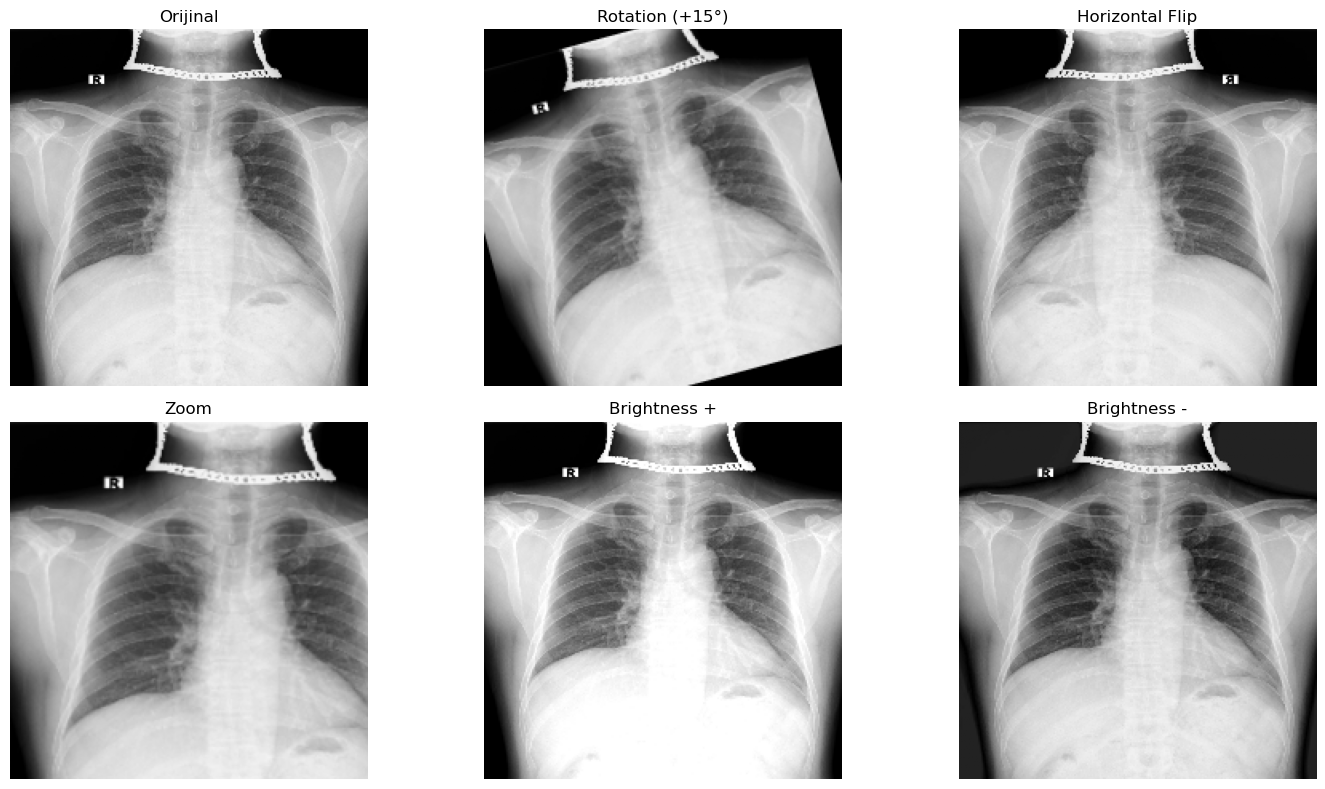

: 

In [ ]:
# Örnek görüntüyü yükle ve yeniden boyutlandır

image = cv2.imread(sample_image_path, cv2.IMREAD_GRAYSCALE)
image = cv2.resize(image, (224, 224))

# Rotation (15 derece döndürme)
rows, cols = image.shape
rotation_matrix = cv2.getRotationMatrix2D((cols/2, rows/2), 15, 1)
rotated = cv2.warpAffine(image, rotation_matrix, (cols, rows))

# Horizontal Flip
flipped = cv2.flip(image, 1)

# Zoom
zoomed = cv2.resize(image, None, fx=1.2, fy=1.2)
zoomed = zoomed[:224, :224]

# Brightness + Parlaklık artırma
bright = cv2.convertScaleAbs(image, alpha=1.0, beta=30)

# Brightness - Parlaklık azaltma
dark = cv2.convertScaleAbs(image, alpha=1.0, beta=-30)

# Veri artırma örneklerini görselleştir

plt.figure(figsize=(15,8))

titles = [
    "Orijinal",
    "Rotation (+15°)",
    "Horizontal Flip",
    "Zoom",
    "Brightness +",
    "Brightness -"
]

images = [
    image,
    rotated,
    flipped,
    zoomed,
    bright,
    dark
]

for i in range(6):

    plt.subplot(2,3,i+1)

    plt.imshow(images[i], cmap="gray")

    plt.title(titles[i])

    plt.axis("off")

plt.tight_layout()
plt.show()

### Data Augmentation Değerlendirmesi

Uygulanan dönüşümler sonucunda görüntülerin farklı varyasyonları elde edilmiştir.

Bu işlemler, modelin yalnızca belirli görüntülere ezber yapmasını engelleyerek farklı görüntü koşullarına karşı daha dayanıklı hale gelmesini sağlamaktadır.

Bu bölümde gösterilen dönüşümler örnek amaçlıdır. Model eğitimi sırasında veri artırma işlemleri otomatik olarak uygulanacaktır.

# C. Model Geliştirme

## 6. Veri Yükleme ve Veri Artırma

Bu bölümde eğitim, doğrulama ve test veri setleri modele uygun formata dönüştürülmüştür.

Eğitim veri setinde veri artırma (Data Augmentation) yöntemleri kullanılmıştır. Böylece modelin farklı görüntü varyasyonlarını öğrenmesi ve aşırı öğrenme (overfitting) riskinin azaltılması amaçlanmıştır.

In [ ]:
# EfficientNet için gerekli preprocessing
from tensorflow.keras.applications.efficientnet import preprocess_input

# Görüntü boyutu

IMG_SIZE = (224, 224)

BATCH_SIZE = 32

# Eğitim veri seti
# Veri artırma işlemleri burada uygulanacaktır
train_datagen = ImageDataGenerator(

    preprocessing_function=preprocess_input,

    rotation_range=15,
    horizontal_flip=True,
    brightness_range=[0.9, 1.1],
    zoom_range=0.1
)

# Validation ve Test

test_datagen = ImageDataGenerator(

    preprocessing_function=preprocess_input
)

# Eğitim veri yükleyicisi

train_generator = train_datagen.flow_from_directory(

    train_dir,

    target_size=IMG_SIZE,

    batch_size=BATCH_SIZE,

    class_mode="binary",

    color_mode="rgb"
)

# Doğrulama veri yükleyicisi


valid_generator = test_datagen.flow_from_directory(

    valid_dir,

    target_size=IMG_SIZE,

    batch_size=BATCH_SIZE,

    class_mode="binary",

    color_mode="rgb"
)

#Test veri yükleyicisi

test_generator = test_datagen.flow_from_directory(

    test_dir,

    target_size=IMG_SIZE,

    batch_size=BATCH_SIZE,

    class_mode="binary",

    color_mode="rgb",

    shuffle=False
)

print("Veri yükleyiciler başarıyla oluşturuldu.")

Found 8554 images belonging to 2 classes.
Found 1070 images belonging to 2 classes.
Found 1070 images belonging to 2 classes.
Veri yükleyiciler başarıyla oluşturuldu.


### Veri Yükleyicilerin Değerlendirilmesi

Eğitim, doğrulama ve test veri setleri başarıyla yüklenmiştir.

Eğitim veri setinde veri artırma işlemleri uygulanırken, doğrulama ve test veri setlerinde yalnızca EfficientNetB0 modeline uygun ön işleme adımları kullanılmıştır.

Bu yaklaşım modelin eğitim sırasında daha fazla çeşitlilik görmesini sağlarken, performans değerlendirmesinin gerçek veri üzerinde yapılmasına olanak tanımaktadır.


## 7. EfficientNetB0 ile Transfer Learning

Bu çalışmada göğüs röntgeni görüntülerinin sınıflandırılması için EfficientNetB0 mimarisi tercih edilmiştir.

Model, ImageNet veri seti üzerinde önceden eğitilmiş ağırlıklarla başlatılmıştır. Böylece modelin genel görüntü özelliklerini önceden öğrenmiş olması sağlanmış ve sınırlı veri ile daha yüksek performans elde edilmesi amaçlanmıştır.

İlk aşamada temel model katmanları dondurulmuş (freeze) ve yalnızca sınıflandırma katmanları eğitilmiştir.

In [ ]:
# EfficientNetB0 modelini içe aktar
from tensorflow.keras.applications import EfficientNetB0

# Sınıflandırma katmanları için gerekli katmanlar
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import GlobalAveragePooling2D

# Model oluşturmak için
from tensorflow.keras.models import Model


# --------------------------------------------------
# Önceden eğitilmiş EfficientNetB0 modelini yükle
# weights="imagenet" sayesinde ImageNet ağırlıkları kullanılır
# include_top=False ile son sınıflandırma katmanları kaldırılır
# --------------------------------------------------

base_model = EfficientNetB0(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)


# --------------------------------------------------
# İlk aşamada transfer learning uygulanacaktır.
# Bu nedenle temel model katmanları dondurulur.
# Sadece sonradan eklenen sınıflandırma katmanları eğitilecektir.
# --------------------------------------------------

base_model.trainable = False



# EfficientNet tarafından çıkarılan özellik haritalarını al


x = base_model.output



# Özellik haritalarını tek vektöre dönüştür
#  Parametre sayısını azaltarak overfitting riskini düşürür


x = GlobalAveragePooling2D()(x)


# --------------------------------------------------
# Overfitting riskini azaltmak için Dropout kullan
# --------------------------------------------------

x = Dropout(0.3)(x)


# --------------------------------------------------
# Binary classification için çıkış katmanı
# 1 nöron + Sigmoid aktivasyonu
# Çıktı 0 ile 1 arasında olasılık değeri üretir
# --------------------------------------------------

output = Dense(
    1,
    activation="sigmoid"
)(x)


# --------------------------------------------------
# Nihai modeli oluştur
# --------------------------------------------------

model = Model(
    inputs=base_model.input,
    outputs=output
)


# --------------------------------------------------
# Model mimarisini görüntüle
# --------------------------------------------------

model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_6         │ (None, 224, 224,  │          0 │ input_layer_3[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization_3     │ (None, 224, 224,  │          7 │ rescaling_6[0][0] │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_7         │ (None, 224, 224,  │          0 │ normalization_3[… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_7[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit

 Total params: 4,050,852 (15.45 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

### Model Özeti

EfficientNetB0 katmanı görüntülerden anlamlı özellikler çıkarmakta, ardından GlobalAveragePooling, Dropout ve Dense katmanları kullanılarak ikili sınıflandırma gerçekleştirilmektedir.

İlk eğitim aşamasında EfficientNetB0 katmanları dondurulmuş ve yalnızca son sınıflandırma katmanı eğitilmiştir. Bu yaklaşım Transfer Learning yönteminin temel uygulamasını oluşturmaktadır.


## 9. Modelin Derlenmesi (Compile)

Model eğitime başlamadan önce kayıp fonksiyonu (Loss Function), optimizasyon algoritması (Optimizer) ve performans metrikleri belirlenmiştir.

Bu çalışma ikili sınıflandırma (Binary Classification) problemi olduğundan Binary Crossentropy kayıp fonksiyonu kullanılmıştır.

Optimizasyon işlemi için Adam algoritması tercih edilmiştir. Adam optimizasyon algoritması, hızlı ve kararlı öğrenme sağlaması nedeniyle derin öğrenme uygulamalarında yaygın olarak kullanılmaktadır.

Ayrıca eğitim sürecini daha verimli hale getirmek amacıyla Early Stopping ve Model Checkpoint mekanizmaları kullanılmıştır.

In [ ]:
# Eğitim sırasında kullanılacak callback yapıları

from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.callbacks import ModelCheckpoint


# --------------------------------------------------
# Modelin derlenmesi
# Optimizer, loss fonksiyonu ve metrikler belirlenir
# --------------------------------------------------

model.compile(

    optimizer="adam",

    loss="binary_crossentropy",

    metrics=[
        "accuracy"
    ]
)


# --------------------------------------------------
# Validation Loss iyileşmezse eğitimi erken durdur
# Overfitting riskini azaltır
# --------------------------------------------------

early_stopping = EarlyStopping(

    monitor="val_loss",

    patience=3,

    restore_best_weights=True
)


# --------------------------------------------------
# Validation Loss'a göre en iyi modeli kaydet
# --------------------------------------------------

checkpoint = ModelCheckpoint(

    "../models/best_efficientnet_model.keras",

    monitor="val_loss",

    save_best_only=True
)

print("Model eğitime hazır.")

Model eğitime hazır.


### Derleme Değerlendirmesi

Model binary sınıflandırma problemine uygun olarak derlenmiştir.

Eğitim sırasında doğrulama kaybı takip edilecek ve model performansında iyileşme görülmezse eğitim erken durdurulacaktır. Ayrıca en iyi model ağırlıkları otomatik olarak kaydedilecektir.

## 9. İlk Eğitim (Transfer Learning)

Bu aşamada yalnızca sınıflandırma katmanları eğitilmiştir.

EfficientNetB0 katmanları dondurulmuş ve ImageNet üzerinde öğrenilmiş özellikler korunmuştur.
Eğitim sürecinde doğrulama veri seti kullanılarak model performansı izlenmiştir.
Amaç, veri setine uygun yeni sınıflandırma katmanlarını eğitmektir.

In [ ]:
# --------------------------------------------------
# İlk eğitim
# Transfer Learning
# --------------------------------------------------
# Bu aşamada yalnızca son sınıflandırma katmanları
# eğitilmektedir.
# EfficientNetB0 katmanları dondurulmuştur.

history = model.fit(

    train_generator,

    validation_data=valid_generator,

    epochs=2,

    callbacks=[
        early_stopping,
        checkpoint
    ]
)

Epoch 1/2
268/268 ━━━━━━━━━━━━━━━━━━━━ 752s 3s/step - accuracy: 0.7017 - loss: 0.5705 - val_accuracy: 0.7654 - val_loss: 0.4995
Epoch 2/2
268/268 ━━━━━━━━━━━━━━━━━━━━ 618s 2s/step - accuracy: 0.7838 - loss: 0.4728 - val_accuracy: 0.7850 - val_loss: 0.4657


## 10. Eğitim Sonuçlarının Görselleştirilmesi

Model eğitimi sırasında elde edilen doğruluk (accuracy) ve kayıp (loss) değerleri grafikler yardımıyla incelenmiştir.

Bu grafikler modelin öğrenme sürecini değerlendirmek amacıyla kullanılmıştır.

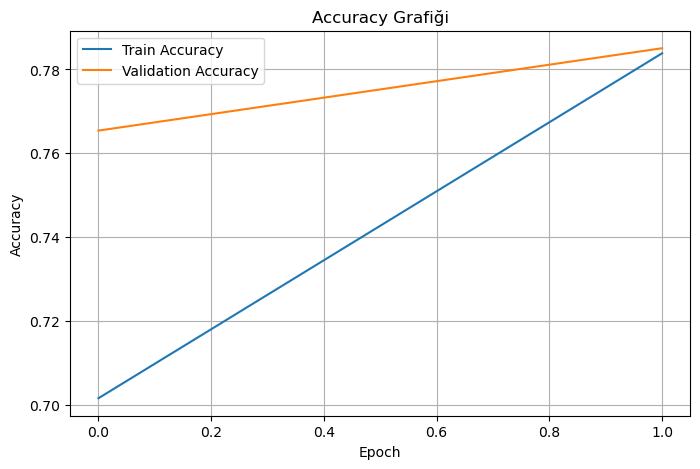

In [36]:
# Accuracy grafiği

plt.figure(figsize=(8,5))

plt.plot(
    history.history["accuracy"],
    label="Train Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title("Accuracy Grafiği")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend()

plt.grid(True)

plt.show()

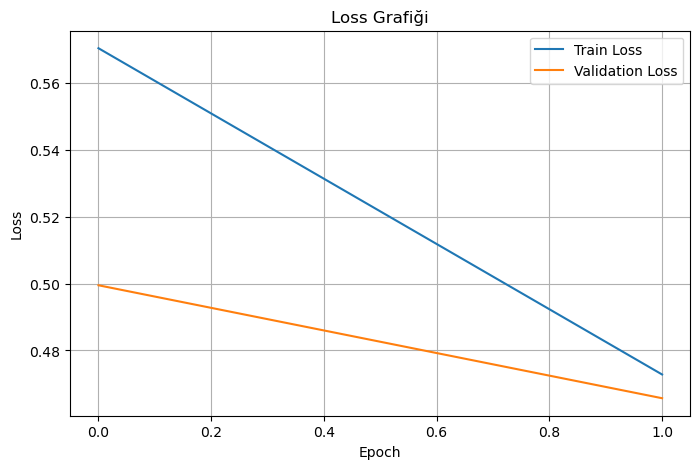

In [37]:
# Loss grafiği

plt.figure(figsize=(8,5))

plt.plot(
    history.history["loss"],
    label="Train Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.title("Loss Grafiği")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.grid(True)

plt.show()

### Eğitim Performansının Değerlendirilmesi

Accuracy grafiği incelendiğinde eğitim ve doğrulama doğruluklarının her epoch sonunda arttığı görülmektedir.

Loss grafiğinde ise hem eğitim hem de doğrulama kaybının azaldığı gözlemlenmiştir. Eğitim ve doğrulama eğrilerinin birbirine yakın seyretmesi modelin aşırı öğrenme (overfitting) göstermediğini düşündürmektedir.

İki epoch sonunda model yaklaşık %78 doğruluk seviyesine ulaşmıştır. Bu sonuç, transfer öğrenme yaklaşımının veri seti üzerinde başarılı şekilde çalıştığını göstermektedir.

## 11. Fine-Tuning

İlk eğitim aşamasında yalnızca sınıflandırma katmanları eğitilmiştir.

Bu aşamada EfficientNetB0 modelinin son katmanları eğitime açılmış ve model göğüs röntgeni veri setine daha iyi uyum sağlayacak şekilde yeniden eğitilmiştir.

Bu yöntem Transfer Learning sürecinin Fine-Tuning aşamasını oluşturmaktadır.

In [38]:
# --------------------------------------------------
# Fine-Tuning
# Son katmanları eğitime aç
# --------------------------------------------------

base_model.trainable = True

# İlk katmanlar dondurulsun
for layer in base_model.layers[:-30]:
    layer.trainable = False

# Son 30 katman eğitilebilir olsun
for layer in base_model.layers[-30:]:
    layer.trainable = True

print("Fine-Tuning için son 30 katman açıldı.")

Fine-Tuning için son 30 katman açıldı.


In [39]:
# --------------------------------------------------
# Fine-Tuning için yeniden derleme
# --------------------------------------------------

from tensorflow.keras.optimizers import Adam

model.compile(

    optimizer=Adam(
        learning_rate=0.00001
    ),

    loss="binary_crossentropy",

    metrics=[
        "accuracy"
    ]
)

print("Model Fine-Tuning için hazır.")

Model Fine-Tuning için hazır.


In [40]:
# --------------------------------------------------
# Fine-Tuning Eğitimi
# --------------------------------------------------

history_finetune = model.fit(

    train_generator,

    validation_data=valid_generator,

    epochs=3,

    callbacks=[
        early_stopping,
        checkpoint
    ]
)

Epoch 1/3
268/268 ━━━━━━━━━━━━━━━━━━━━ 600s 2s/step - accuracy: 0.7718 - loss: 0.4913 - val_accuracy: 0.8206 - val_loss: 0.4201
Epoch 2/3
268/268 ━━━━━━━━━━━━━━━━━━━━ 590s 2s/step - accuracy: 0.7985 - loss: 0.4405 - val_accuracy: 0.8346 - val_loss: 0.3889
Epoch 3/3
268/268 ━━━━━━━━━━━━━━━━━━━━ 685s 3s/step - accuracy: 0.8195 - loss: 0.4069 - val_accuracy: 0.8449 - val_loss: 0.3687


### Fine-Tuning Sonuçlarının Değerlendirilmesi

Fine-Tuning aşamasında EfficientNetB0 modelinin son katmanları eğitime açılmıştır.

Üç epoch sonunda doğrulama doğruluğu %84.49 seviyesine ulaşmıştır. İlk Transfer Learning aşamasında elde edilen %78.50 doğruluk ile karşılaştırıldığında model performansında belirgin bir iyileşme gözlenmiştir.

Ayrıca doğrulama kaybının her epoch sonunda azalması, modelin veri setine daha iyi uyum sağladığını göstermektedir.

## 12. Fine-Tuning Eğitim Grafikleri

Fine-Tuning aşamasında modelin son katmanları eğitime açılmıştır.

Bu bölümde doğruluk (accuracy) ve kayıp (loss) değişimleri incelenerek model performansındaki gelişim değerlendirilmiştir.

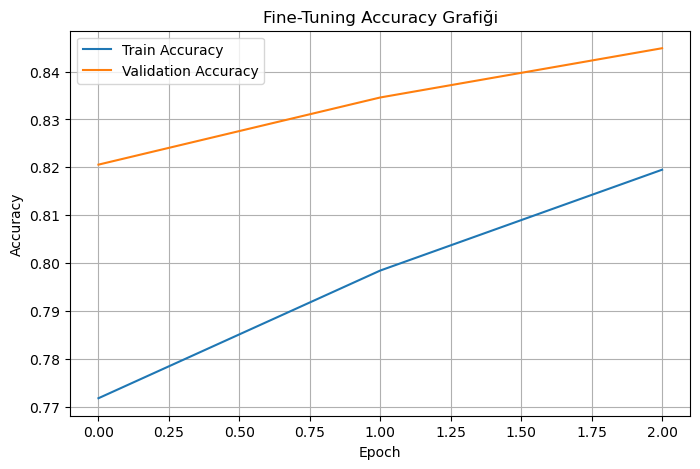

In [41]:
# Fine-Tuning Accuracy Grafiği

plt.figure(figsize=(8,5))

plt.plot(
    history_finetune.history["accuracy"],
    label="Train Accuracy"
)

plt.plot(
    history_finetune.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title("Fine-Tuning Accuracy Grafiği")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend()

plt.grid(True)

plt.show()

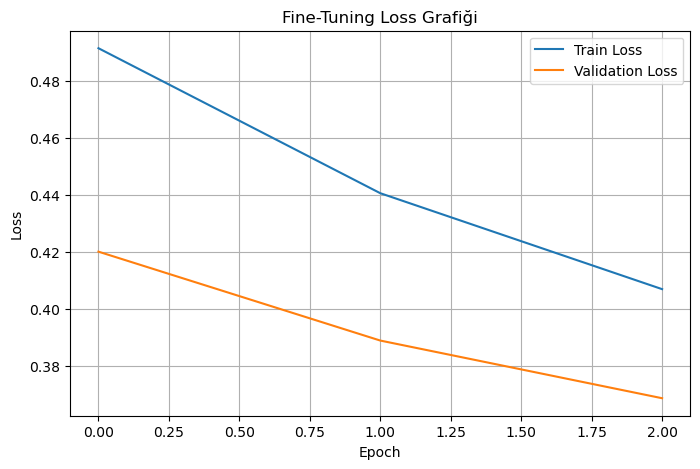

In [42]:
# Fine-Tuning Loss Grafiği

plt.figure(figsize=(8,5))

plt.plot(
    history_finetune.history["loss"],
    label="Train Loss"
)

plt.plot(
    history_finetune.history["val_loss"],
    label="Validation Loss"
)

plt.title("Fine-Tuning Loss Grafiği")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.grid(True)

plt.show()

### Fine-Tuning Performans Değerlendirmesi

Fine-Tuning sonrasında modelin doğruluk oranında sürekli artış gözlenmiştir.

Validation Accuracy değeri %82.06'dan %84.49'a yükselmiştir. Aynı zamanda Validation Loss değeri 0.4201'den 0.3687'ye düşmüştür.

Bu sonuçlar, EfficientNetB0 modelinin son katmanlarının veri setine uyum sağlayarak daha ayırt edici özellikler öğrenebildiğini göstermektedir.

İlk Transfer Learning aşamasına göre yaklaşık %6 doğruluk artışı elde edilmiştir.

## 13. Test Performansının Değerlendirilmesi

Bu bölümde model test veri seti üzerinde değerlendirilmiştir.

Accuracy değerine ek olarak Sensitivity (Recall), F1-Score, AUC-ROC ve Confusion Matrix metrikleri hesaplanmıştır.

Tıbbi görüntü sınıflandırma problemlerinde özellikle Recall (Sensitivity) değeri kritik öneme sahiptir çünkü hastalıklı görüntülerin kaçırılmaması hedeflenmektedir.

In [43]:
# --------------------------------------------------
# Test tahminleri
# --------------------------------------------------

import numpy as np

pred_probs = model.predict(test_generator)

predictions = (pred_probs > 0.5).astype(int)

y_true = test_generator.classes

print("Tahminler oluşturuldu.")

34/34 ━━━━━━━━━━━━━━━━━━━━ 89s 3s/step
Tahminler oluşturuldu.


In [44]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_true,
        predictions,
        target_names=["Normal", "Anormal"]
    )
)

              precision    recall  f1-score   support

      Normal       0.88      0.84      0.86       535
     Anormal       0.85      0.88      0.87       535

    accuracy                           0.86      1070
   macro avg       0.86      0.86      0.86      1070
weighted avg       0.86      0.86      0.86      1070



In [45]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_true,
    predictions
)

print(cm)

[[452  83]
 [ 63 472]]


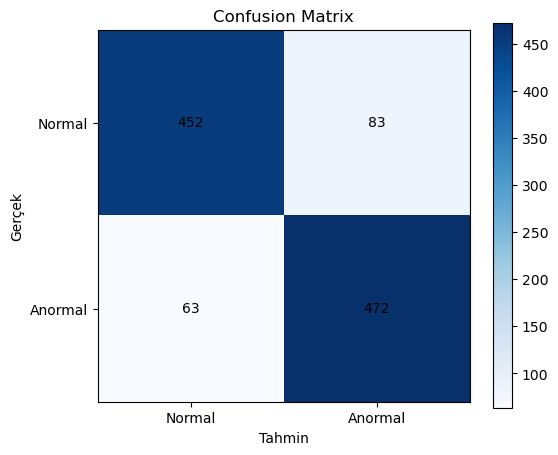

In [48]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))

plt.imshow(cm, cmap="Blues")

plt.title("Confusion Matrix")

plt.colorbar()

plt.xticks([0,1], ["Normal","Anormal"])
plt.yticks([0,1], ["Normal","Anormal"])

plt.xlabel("Tahmin")
plt.ylabel("Gerçek")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(
            j,
            i,
            str(cm[i, j]),
            ha="center",
            va="center"
        )

plt.show()

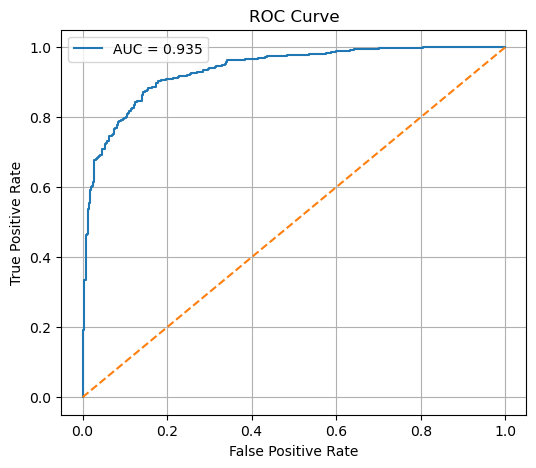

AUC: 0.9350510961656039


In [47]:
from sklearn.metrics import roc_curve
from sklearn.metrics import auc

fpr, tpr, thresholds = roc_curve(
    y_true,
    pred_probs
)

roc_auc = auc(
    fpr,
    tpr
)

plt.figure(figsize=(6,5))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {roc_auc:.3f}"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.grid()

plt.show()

print("AUC:", roc_auc)

In [57]:
# --------------------------------------------------
# Specificity Hesaplama
# --------------------------------------------------

TN = cm[0,0]
FP = cm[0,1]

specificity = TN / (TN + FP)

print("Specificity:", round(specificity,4))

Specificity: 0.8449


### Test Sonuçlarının Değerlendirilmesi

Model test veri seti üzerinde %86 doğruluk elde etmiştir.

Anormal sınıf için Recall (Sensitivity) değeri %88 olarak hesaplanmıştır. Bu sonuç modelin hastalıklı görüntülerin büyük kısmını başarıyla tespit edebildiğini göstermektedir.

Confusion Matrix incelendiğinde modelin 472 anormal görüntüyü doğru sınıflandırdığı, yalnızca 63 anormal görüntüyü kaçırdığı görülmüştür.

ROC-AUC değeri 0.935 olarak elde edilmiştir. Bu sonuç modelin normal ve anormal sınıfları ayırt etme konusunda yüksek performans gösterdiğini ortaya koymaktadır.

## 14. Attention Mechanism (SE Block)

Görüntü sınıflandırma problemlerinde bazı bölgeler diğer bölgelere göre daha önemli bilgiler içerebilir.

Bu nedenle modele Squeeze-and-Excitation (SE) Attention mekanizması eklenmiştir. Bu yapı, modelin önemli özelliklere daha fazla odaklanmasını sağlayarak sınıflandırma performansını artırmayı amaçlamaktadır.

In [49]:
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Reshape
from tensorflow.keras.layers import Multiply


# --------------------------------------------------
# Squeeze and Excitation (SE) Block
# --------------------------------------------------

def se_block(input_tensor, ratio=16):

    channels = input_tensor.shape[-1]

    se = GlobalAveragePooling2D()(input_tensor)

    se = Dense(
        channels // ratio,
        activation="relu"
    )(se)

    se = Dense(
        channels,
        activation="sigmoid"
    )(se)

    se = Reshape((1,1,channels))(se)

    output = Multiply()([input_tensor, se])

    return output

## 15. EfficientNetB0 + SE Attention Modeli

Bu aşamada EfficientNetB0 mimarisine SE Attention bloğu eklenmiştir.

Amaç, modelin önemli özellik kanallarına daha fazla ağırlık vererek anormal bulguları daha iyi ayırt edebilmesini sağlamaktır.

In [51]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.models import Model


# --------------------------------------------------
# EfficientNetB0 taban modelini oluştur
# ImageNet ağırlıkları kullanılır
# --------------------------------------------------

attention_base_model = EfficientNetB0(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)


# --------------------------------------------------
# İlk aşamada EfficientNet katmanlarını dondur
# --------------------------------------------------

attention_base_model.trainable = False


# --------------------------------------------------
# EfficientNet çıktısını al
# --------------------------------------------------

x = attention_base_model.output


# --------------------------------------------------
# SE Attention bloğunu EfficientNet çıktısına ekle
# --------------------------------------------------

x = se_block(x)


# --------------------------------------------------
# Özellikleri sınıflandırma için tek vektöre dönüştür
# --------------------------------------------------

x = GlobalAveragePooling2D()(x)


# --------------------------------------------------
# Overfitting'i azaltmak için Dropout kullan
# --------------------------------------------------

x = Dropout(0.3)(x)


# --------------------------------------------------
# Binary classification çıkış katmanı
# --------------------------------------------------

output = Dense(
    1,
    activation="sigmoid"
)(x)


# --------------------------------------------------
# Attention destekli modeli oluştur
# --------------------------------------------------

attention_model = Model(
    inputs=attention_base_model.input,
    outputs=output
)


attention_model.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_8         │ (None, 224, 224,  │          0 │ input_layer_4[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization_4     │ (None, 224, 224,  │          7 │ rescaling_8[0][0] │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_9         │ (None, 224, 224,  │          0 │ normalization_4[… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_9[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit

 Total params: 4,257,012 (16.24 MB)

 Trainable params: 207,441 (810.32 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [52]:
# --------------------------------------------------
# Attention Modelini Derle
# --------------------------------------------------

from tensorflow.keras.optimizers import Adam

attention_model.compile(

    optimizer=Adam(
        learning_rate=0.0001
    ),

    loss="binary_crossentropy",

    metrics=[
        "accuracy"
    ]
)

print("Attention modeli eğitime hazır.")

Attention modeli eğitime hazır.


In [53]:
# --------------------------------------------------
# Attention Modeli Eğitimi
# --------------------------------------------------

history_attention = attention_model.fit(

    train_generator,

    validation_data=valid_generator,

    epochs=3,

    callbacks=[
        early_stopping
    ]
)

Epoch 1/3
268/268 ━━━━━━━━━━━━━━━━━━━━ 584s 2s/step - accuracy: 0.6242 - loss: 0.6452 - val_accuracy: 0.7019 - val_loss: 0.5856
Epoch 2/3
268/268 ━━━━━━━━━━━━━━━━━━━━ 563s 2s/step - accuracy: 0.7544 - loss: 0.5260 - val_accuracy: 0.7682 - val_loss: 0.4876
Epoch 3/3
268/268 ━━━━━━━━━━━━━━━━━━━━ 1612s 6s/step - accuracy: 0.7927 - loss: 0.4595 - val_accuracy: 0.8028 - val_loss: 0.4488


In [54]:
# --------------------------------------------------
# Attention modeli için Fine-Tuning
# --------------------------------------------------

attention_base_model.trainable = True

for layer in attention_base_model.layers[:-30]:
    layer.trainable = False

for layer in attention_base_model.layers[-30:]:
    layer.trainable = True

print("Attention modeli için Fine-Tuning aktif.")

Attention modeli için Fine-Tuning aktif.


In [55]:
from tensorflow.keras.optimizers import Adam

attention_model.compile(

    optimizer=Adam(
        learning_rate=0.00001
    ),

    loss="binary_crossentropy",

    metrics=["accuracy"]
)

print("Attention + Fine-Tuning modeli hazır.")

Attention + Fine-Tuning modeli hazır.


In [56]:
history_attention_finetune = attention_model.fit(
    train_generator,
    validation_data=valid_generator,
    epochs=3,
    callbacks=[early_stopping]
)

Epoch 1/3
268/268 ━━━━━━━━━━━━━━━━━━━━ 685s 2s/step - accuracy: 0.6782 - loss: 0.6331 - val_accuracy: 0.7364 - val_loss: 0.5725
Epoch 2/3
268/268 ━━━━━━━━━━━━━━━━━━━━ 697s 3s/step - accuracy: 0.7574 - loss: 0.5637 - val_accuracy: 0.7738 - val_loss: 0.5095
Epoch 3/3
268/268 ━━━━━━━━━━━━━━━━━━━━ 699s 3s/step - accuracy: 0.7949 - loss: 0.4950 - val_accuracy: 0.7981 - val_loss: 0.4519


### Attention Mekanizmasının Değerlendirilmesi

Bu çalışmada EfficientNetB0 mimarisine SE Attention mekanizması entegre edilmiştir.

Attention destekli model ile gerçekleştirilen deneylerde doğrulama doğruluğu yaklaşık %80 seviyesinde elde edilmiştir. Ancak Fine-Tuning uygulanmış temel EfficientNetB0 modeli %84.49 doğruluk değeri ile daha yüksek performans göstermiştir.

Bu sonuç, kullanılan veri seti ve model yapısı için SE Attention mekanizmasının ek bir performans artışı sağlamadığını göstermektedir. Buna rağmen Attention yaklaşımı başarıyla uygulanmış ve performansı deneysel olarak değerlendirilmiştir.